# NeRF

**To run NeRF, first run the COLMAP pipeline to get the poses and focal**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import trimesh
from skimage import measure
import open3d as o3d
import sys
sys.path.append("../utils")
from colmap import load_nerf_data_from_colmap
from nerf import train, NeRF, extract_mesh, color_mesh, save_mesh, extract_point_cloud, color_point_cloud, save_point_cloud
from mesh_transforming import poisson_reconstruction_from_point_cloud

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load Data

Pose normalisation: scene_center=[0.04145127 0.07897662 0.12253687], scale=1.1803
  Camera distance range after scaling: 2.221 – 6.510
  Suggested near=1.11, far=9.77
(99, 600, 600, 3) (99, 4, 4) 823.9832624520693 600 600
Using device: cuda
Pose example:
 [[-0.4450562   0.2723556  -0.8530811  -4.2519956 ]
 [ 0.7649514  -0.3796662  -0.5202912  -2.0275223 ]
 [-0.4655903  -0.8841244  -0.03936598  2.857107  ]
 [ 0.          0.          0.          1.        ]]


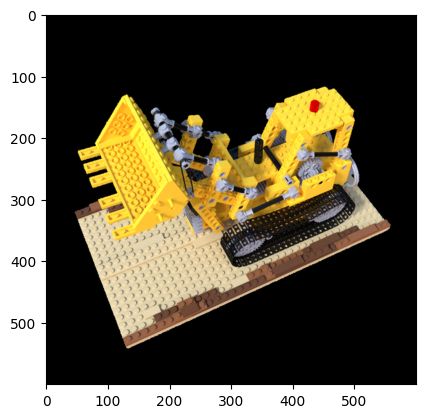

In [ ]:
train_images, train_poses, focal, test_images, test_poses = load_nerf_data_from_colmap(
    model_dir = "../results/colmap/0",
    images_dir = "../data/",
    #image_size = (600, 600), # optional resize
    normalize_poses = True,  # centres scene and scales cameras to r≈4 (near=2/far=6)
)

H, W = train_images.shape[1:3]
print(train_images.shape, train_poses.shape, focal, H, W)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Pose example:\n", train_poses[0])
plt.imshow(test_images[0])
plt.show()
focal = np.array(focal)
testimg = torch.from_numpy(test_images[0]).float().to(device)
testpose = torch.from_numpy(test_poses[0]).float().to(device)

## Train Model

In [ ]:
n_iter = 100000
n_samples = 64
i_plot = 10000  # Interval for plotting
i_val = 1000     # Interval for calculating val_loss

model = train(train_images, train_poses, H, W, focal, testpose, testimg, n_iter, n_samples, i_plot, i_val, device)

## Save the model

In [ ]:
save_dir = Path("../results/nerf")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "nerf_model.pt"
torch.save(model.state_dict(), model_path)

print(f"Saved trained model to: {model_path.resolve()}")

Saved trained model to: C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf\nerf_model.pt


## Load the model

In [2]:
save_dir = Path("../results/nerf")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "nerf_model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = NeRF().to(device)

# Load saved weights into the existing model instance
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print(f"Loaded model from: {model_path.resolve()}")

Loaded model from: C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf\nerf_model.pt


In [3]:
train_images, train_poses, focal, test_images, test_poses = load_nerf_data_from_colmap(
    model_dir = "../results/colmap/0",
    images_dir = "../data",
    #image_size = (600, 600), # optional resize
    normalize_poses = True,  # centres scene and scales cameras to r≈4 (near=2/far=6)
)

H, W = train_images.shape[1:3]
focal = np.array(focal)

Pose normalisation: scene_center=[0.04145127 0.07897662 0.12253687], scale=1.1803
  Camera distance range after scaling: 2.221 – 6.510
  Suggested near=1.11, far=9.77


## Extract Mesh

In [4]:
verts, faces = extract_mesh(
    model,
    bound=4,
    resolution=512,
    density_threshold=5.0,
    device=device,
)

Density  min=0.000  max=220.871  mean=0.728  — adjust density_threshold accordingly


In [5]:
colors = color_mesh(verts, train_poses, model, device=device)

In [6]:
mesh   = save_mesh(verts, faces, colors, "../results/nerf/nerf_mesh.ply")

Saved → ../results/nerf/nerf_mesh.ply  (1,140,384 verts, 2,265,010 faces)


## Convert to point Cloud

In [7]:
# 1. Extract surface points
xyz, sigmas = extract_point_cloud(
    model,
    bound=4.0,
    resolution=512,
    density_threshold=5.0,   # same value you tuned for the mesh
    device=device,
)

# 2. Color and filter black points
xyz, colors = color_point_cloud(
    xyz, sigmas, train_poses, model,
    black_threshold=0.2,  # raise if too many dark points survive
    device=device,
)

# 3. Save
cloud = save_point_cloud(xyz, colors, "../results/nerf/nerf_pointcloud.ply")

Points above threshold: 3,173,105 / 134,217,728
Removed 2,706,721 black points (85.3%)
Saved → ../results/nerf/nerf_pointcloud.ply  (466,384 points)


## Convert back to mesh

In [8]:
# Example: read the PLY we saved earlier, clean it, and visualize
ply_path = '../results/nerf/nerf_pointcloud.ply'
try:
    pcd = o3d.io.read_point_cloud(ply_path)
except Exception:
    pcd = None

if pcd is None or len(pcd.points) == 0:
    print(f'Could not read {ply_path} or file empty — you can call save_pts3d_ply first or pass another path.')
else:
    print(f'Loaded {len(pcd.points)} points from {ply_path}')
    o3d.visualization.draw_geometries([pcd], mesh_show_back_face=True)

Loaded 466384 points from ../results/nerf/nerf_pointcloud.ply


In [9]:
mesh = poisson_reconstruction_from_point_cloud(pcd, '../results/nerf/Reconstruction_mesh.ply')

o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

Estimating normals...
Running Poisson surface reconstruction...
[Open3D DEBUG] Input Points / Samples: 466384 / 466384
[Open3D DEBUG] #   Got kernel density: 10.305000066757202 (s), 9197.6171875 (MB) / 9197.6171875 (MB) / 9197 (MB)
[Open3D DEBUG] #     Got normal field: 3.9210000038146973 (s), 11984.484375 (MB) / 11984.484375 (MB) / 11984 (MB)
[Open3D DEBUG] Point weight / Estimated Area: 8.679161e-06 / 4.047822e+00
[Open3D DEBUG] #       Finalized tree: 8.723000049591064 (s), 12003.2890625 (MB) / 12003.2890625 (MB) / 14841 (MB)
[Open3D DEBUG] #  Set FEM constraints: 1.1589999198913574 (s), 9218.796875 (MB) / 12003.2890625 (MB) / 14841 (MB)
[Open3D DEBUG] #Set point constraints: 1.2689998149871826 (s), 9181.68359375 (MB) / 12003.2890625 (MB) / 14841 (MB)
[Open3D DEBUG] Leaf Nodes / Active Nodes / Ghost Nodes: 99279321 / 3041824 / 110420257
[Open3D DEBUG] Memory Usage: 9181.688 MB
[Open3D DEBUG] # Linear system solved: 11.059999942779541 (s), 9270.4453125 (MB) / 12003.2890625 (MB) / 148